
#**Superstore Sales Analysis**

## Introduction

This notebook analyzes the Superstore dataset to uncover key business insights related to sales, profit, and regional performance. The goal is to identify trends, highlight opportunities, and support data-driven decision-making.




##  Key Questions
  Which categories and segments drive profit?
  
  How do discounts affect profitability?
  
  Which regions and states underperform?
  
  What are the most valuable customers/products?

---


In [73]:

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

file_path = "/content/drive/MyDrive/Sample-Superstore.csv"
df = pd.read_csv(file_path, encoding='latin-1')
df.head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Understanding

In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [76]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Observations
The dataset contains sales, profit, category, region, and customer-related fields.

Data types appear mostly appropriate but will be validated further.

## Data Cleaning & Preparation

In [77]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [78]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

## Sales & Profit Overview

In [79]:

df[['Sales','Profit']].describe()


,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


### Sales vs Profit

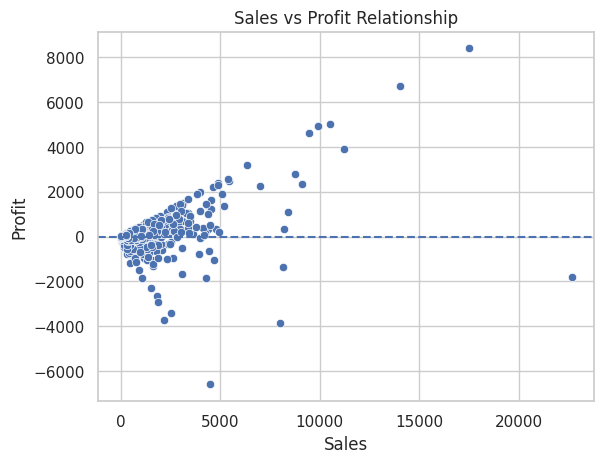

In [80]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit Relationship')
plt.axhline(0, linestyle='--')
plt.show()

Insight: Many points lie below zero profit line -> losses
Even high sales can result in negative profit

Revenue growth is not sustainable without margin control

Action:

Monitor profit per transaction, not just sales volume

##Category Performance (Revenue vs Profit)

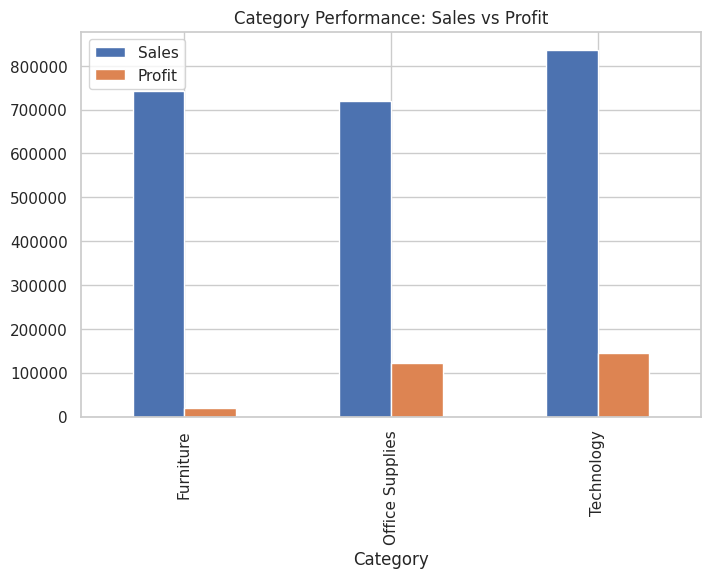

In [81]:
df.groupby('Category')[['Sales','Profit']].sum().plot(kind='bar', figsize=(8,5))
plt.title('Category Performance: Sales vs Profit')
plt.show()

Insight
Some categories:
High Sales but Low Profit -> inefficient

Not all products contribute equally to business success

Action:

Focus on high-margin categories, not just top-selling ones

### Profit by Segment

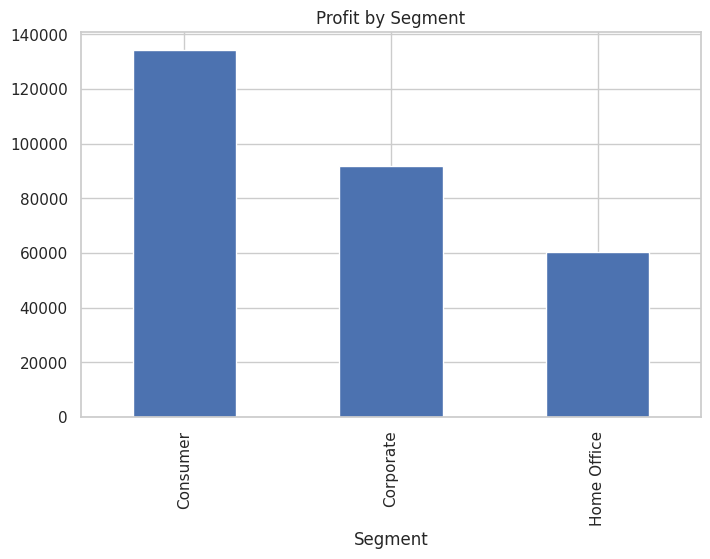

In [102]:

df.groupby('Segment')['Profit'].sum().plot(kind='bar' ,figsize=(8,5))
plt.title('Profit by Segment')
plt.show()



Insight: Corporate or Consumer segments often generate more stable profits.


### Regional Performance

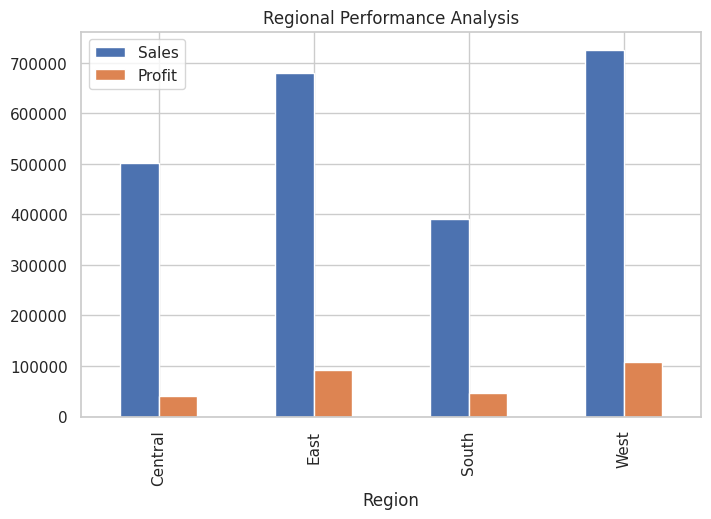

In [83]:
df.groupby('Region')[['Sales','Profit']].sum().plot(kind='bar', figsize=(8,5))
plt.title('Regional Performance Analysis')
plt.show()

Insight: Some regions generate strong sales but weak profit

Operational inefficiencies or pricing issues exist regionally

Action:

Optimize pricing/logistics per region

## Discount Impact Analysis

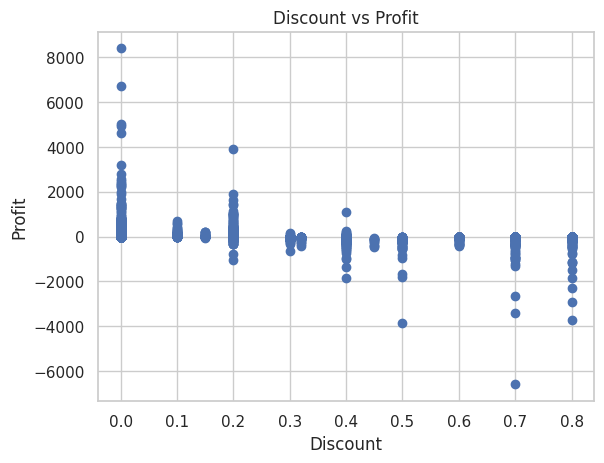

In [84]:

plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()



 Insight: High discounts strongly correlate with losses.


## Top 10 Products

In [85]:

df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)


,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


### Monthly Sales Trend

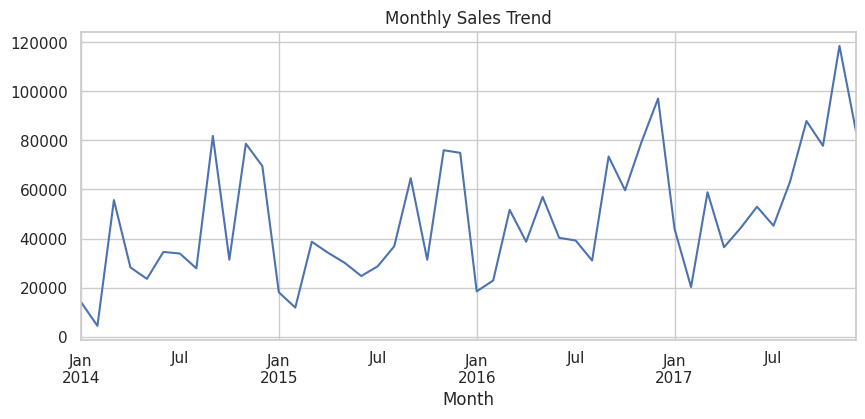

In [92]:
df['Month'] = df['Order Date'].dt.to_period('M')
trend = df.groupby('Month')['Sales'].sum()
trend.plot(figsize=(10,4))
plt.title('Monthly Sales Trend')
plt.show()

Insight: Sales fluctuate across time -> seasonal behavior
Demand is not constant

Action:

Align marketing + inventory with peak periods

## Yearly Sales Trend

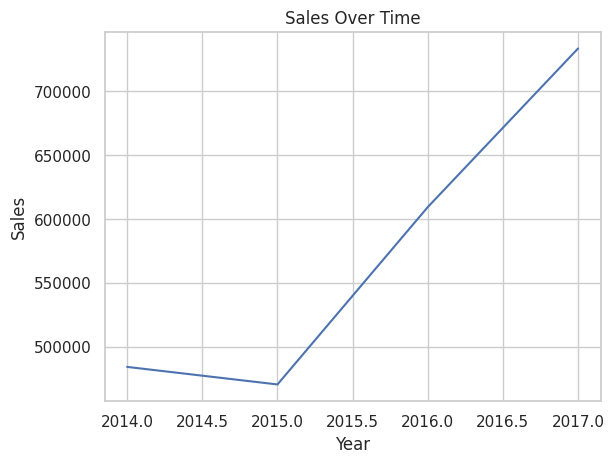

In [88]:

df.groupby('Year')['Sales'].sum().plot(kind='line')
plt.title('Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()


Insight: Growth trends help forecast future demand.

### Sales Distribution

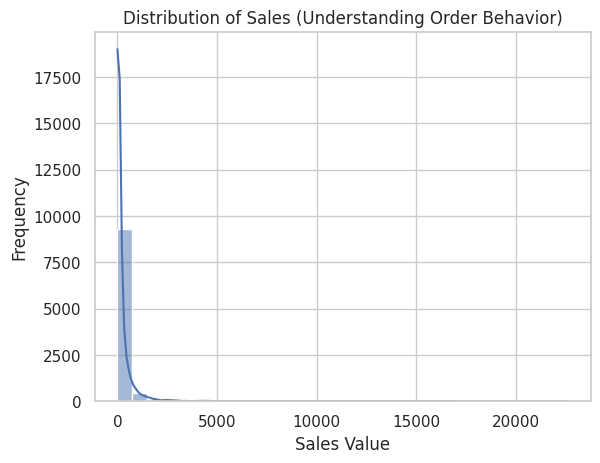

In [89]:
tplt = sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales (Understanding Order Behavior)')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.show()

Insight : The distribution is heavily right-skewed, meaning:

    ~80-90% of orders are low-value transactions
    
    A very small percentage drives disproportionately high revenue

The business is dependent on a minority of high-value customers
Losing these customers would significantly impact revenue

Action:Identify and retain high-value customers (VIP strategy)

### Outlier Analysis (Boxplot)

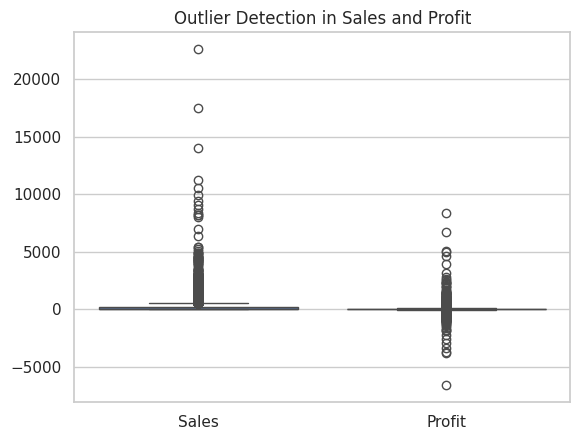

In [90]:
sns.boxplot(data=df[['Sales','Profit']])
plt.title('Outlier Detection in Sales and Profit')
plt.show()

Insight: Numerous extreme outliers exist in both Sales and Profit
Profit shows both very high gains and deep losses

Some transactions are highly profitable
Others are loss-making despite high sales

Action:

Investigate loss-making large orders -> pricing or discount issues

### Correlation Analysis

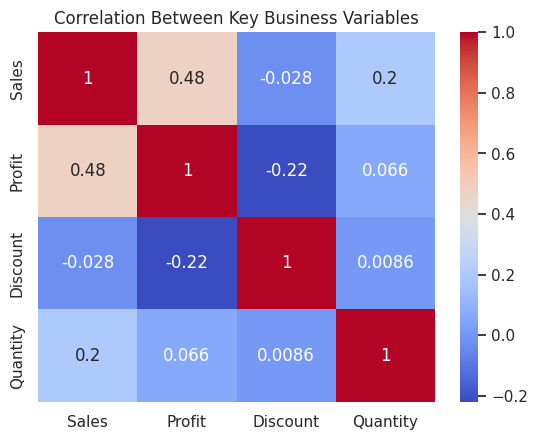

In [91]:
corr = df[['Sales','Profit','Discount','Quantity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Business Variables')
plt.show()

Insight: Discount vs Profit -> Strong Negative Relationship
Sales does NOT strongly guarantee Profit

Increasing sales through discounts is hurting profitability

Action:

Shift from sales-driven strategy -> profit-driven strategy

### Advanced Metric: Profit Margin

In [96]:
df['Profit_Margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)
print(df[['Profit', 'Sales', 'Profit_Margin']].head())


     Profit     Sales  Profit_Margin
0   41.9136  261.9600         0.1600
1  219.5820  731.9400         0.3000
2    6.8714   14.6200         0.4700
3 -383.0310  957.5775        -0.4000
4    2.5164   22.3680         0.1125


Insight: Profit margin reveals true efficiency
Some high-sales orders have very low or negative margin. Revenue ≠ profitability

Action:

Track margin as a core KPI


# Final Business Insights

1, The business relies heavily on a small number of high-value transactions, meaning a few large orders contribute a significant share of total revenue. This creates risk if these key customers are lost.

2, Discounting is a major driver of reduced profitability. While it increases sales volume, excessive discounts often erode margins and can turn sales into losses.
3, There is a clear gap between sales and profit, showing that higher revenue does not always lead to better financial performance. Profit margin is a more reliable measure of success.

4, Analysis reveals hidden losses in some large transactions, indicating issues with pricing or discount strategies.

5, Performance differs across categories and regions, with some areas generating strong sales but weak profit, suggesting inefficiencies.

6, Sales show seasonal patterns, meaning demand changes over time and can be better planned for.


---


# Strategic Recommendations

Optimize discounting to balance sales growth and profitability

Focus on high-margin products instead of just high sales

Improve performance in low-profit regions
Retain and target high-value customers

Use data-driven pricing to avoid loss-making sales


---


# Conclusion
This analysis reveals a critical insight: the business is currently revenue-focused but not profit-optimized. Heavy discounting, inefficient product categories, and regional inconsistencies are reducing overall profitability. To improve performance, the company must shift toward a margin-focused strategy, prioritize high-value customers, and optimize pricing and operations. Doing so will transform revenue growth into sustainable profit growth.

